# Using meshes generated in twistTranslate-box
 - 5 degrees rotation
 - 1 mm translation
 - no combinations

# Experimental data from 20260611
- 1 mm/min testing
- Better calibration range (see moreCalibration.ipynb)
- Masked the raw values ≤ 4

In [114]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd_helpers.AbaqusPostprocessing import inp2pv, get_history_path, get_field_path, get_field_df, add_field_to_mesh
from phd_helpers.experiments import build_sensor_mesh, get_sensor_loc, project_sensor_new

In [115]:
def get_step_ids(inp_file):
    history_files = list(inp_file.parent.glob('resultCSVs/history*.csv'))
    step_ids = np.sort(np.unique([int(x.with_suffix('').name.replace('history_step-', '')) for x in history_files]))
    return step_ids

def fea_mets_from_mesh(mesh):
    return {
        'CA': mesh.field_data['CA'][0],
        'P_max': mesh.field_data['P_max'][0],
        'P_avg': mesh.field_data['P_avg'][0],
        'loc_Pmax': mesh.field_data['loc_Pmax'],
    }

def find_boundary_cells(a):
    """
    input: NxM array of cells
    Returns: NxM (1, 0) array of non-zero cells that border a zero"""
    a = np.asarray(a)
    m = a > 0
    out = np.zeros(a.shape, dtype=bool)

    out[1:, :]  |= m[1:, :]  & (a[:-1, :] == 0)
    out[:-1, :] |= m[:-1, :] & (a[1:, :] == 0)
    out[:, 1:]  |= m[:, 1:]  & (a[:, :-1] == 0)
    out[:, :-1] |= m[:, :-1] & (a[:, 1:] == 0)

    return out

def compute_img_metrics(img, sensel_area=1.6129):

    CA = len(img[img>0]) * sensel_area
    # CA error - between 25% and 125% of the area of the boundary cells 
    # - plenty of cases that could exceed these limits but still reasonable limits I think...
    # - Given the nature of the contacting surfaces, it would be impossible for every boundary cell to be an edge case 
    # - so error bars based on those would give unreasonably wide range
    CA_e_low = find_boundary_cells(img).sum() * sensel_area * 0.75 # lower bound error bar for CA
    CA_e_high = find_boundary_cells(img).sum() * sensel_area * 0.25 # upper bound error bar for CA
    
    P_max = img.max()
    P_avg = img[img>0].mean()
    loc_Pmax = np.array(np.where(img==img.max())).ravel() # idx - (i, j)

    return {
        'CA': CA,
        'CA_e_low': CA_e_low,
        'CA_e_high': CA_e_high,
        'P_max': P_max,
        'P_avg': P_avg,
        'loc_Pmax': loc_Pmax
    }

def compute_CA_overlap(img_fea, img_tek):
    mask_fea = (img_fea > 0)
    mask_tek = (img_tek > 0)
    CA_mean = (mask_fea.sum() + mask_tek.sum()) / 2
    CA_overlap = (mask_fea & mask_tek).sum()

    return 100-(100 * (CA_mean - CA_overlap) / CA_mean)

In [116]:
def compute_Pavg(mesh):
    """Converts CPRESS to cell data and computes area weighted average pressure"""
    tet_surf = mesh.extract_cells_by_type(10).extract_surface(algorithm=None)
    P = tet_surf.point_data_to_cell_data().cell_data['CPRESS'] 
        # CPRESS comes as point data
        # this assigns to each elements CPRESS value, the average of the CPRESS of the 3 points of the element
        # Edge case: elements has point CPRESS = [0, 0, 1.5], element given CPRESS = 0.5, but entire area considered in contact for avg
        # This slightly overestimates area and therefore reduces average pressure
    A = tet_surf.compute_cell_sizes()["Area"]
    mask = P > 0

    return np.sum(P[mask] * A[mask]) / np.sum(A[mask])

def get_fe_data(csv_dir, Fs, bone='tpm'):
    inp_file = list(csv_dir.parent.glob('*.inp'))[0]

    force_steps = get_step_ids(inp_file)[1:]

    frame = -1 # final frame of each step
    field_metrics = ["CPRESS", "U"]


    fea_data = {} # {F1: {'tpm':mesh1, 'mc1':mesh1}, ...} - each mesh contains all fea data
    for step, F in zip(force_steps, Fs):
        #meshes = meshes_orig.copy()
        meshes = inp2pv(inp_file)
        for bone, mesh in meshes.items():
            instance = f"{bone.upper()}_INST"
            
            # Field data
            for metric in field_metrics:
                field_path = get_field_path(csv_dir, metric, step, frame, instance)
                field_df = get_field_df(field_path)
                add_field_to_mesh(mesh, field_df)

            # History data
            history_data = pd.read_csv(get_history_path(csv_dir, step))
            # F
            #RF_data = history_data[history_data['historyOutputKey']=='RF1']
            #RF = np.abs(RF_data['value'].iloc[frame])
            # A
            CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']
            CA = CAREA_data['value'].iloc[frame]

            mesh.field_data['RF'] = F
            mesh.field_data['CA'] = CA

            #P_avg = np.mean(mesh['CPRESS'][mesh['CPRESS']>0])
            #Summary data
            mesh.field_data['P_max'] = mesh['CPRESS'].max()
            mesh.field_data['P_avg'] = compute_Pavg(mesh)
            mesh.field_data['loc_Pmax'] = np.array(mesh.points[np.argmax(mesh['CPRESS'])])

        fea_data[F] = meshes

    return fea_data

def get_fe_grid_data(fea_data, Fs, tek_data, bone='tpm'):

    fea_grid_data = {}
    for F in Fs:

        surf = fea_data[F][bone].extract_surface(algorithm=None)
        mesh = surf.extract_cells(surf[f'{bone}_CART_SURF']==1).extract_surface(algorithm=None)

        sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-2, sensor_size=13.97) # skinny guide ledge
        sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)
        
        fea_grid_new = project_sensor_new(
            mesh=mesh,
            sensor=sensor,
            sensor_vals=tek_data[F],
            data_loc="cells",
            downscale_fea=True,
            return_fea_grid=True,
            active_sensel_width=0.635,  # use your model units
            pressure_name="CPRESS",
        )
        
        
        fea_grid_data[F] = fea_grid_new

    return fea_grid_data

In [117]:
names = ['original', 'Rx', 'Ry', 'Rz', 'ty', 'tz']
path = Path('../../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/TwistTranslate/study1/aire/output/study1')

# Load FE data

In [118]:
Fs = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150] # N

orig_path = Path('../../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_35T4d5_Fsteps/inpFiles/14548R/inp/35T-neutral-00/resultCSVs')
fe = get_fe_data(orig_path, Fs)

fe_Rx = get_fe_data(path / f'14548R-Rx-neutral-00/resultCSVs', Fs)
fe_Ry = get_fe_data(path / f'14548R-Ry-neutral-00/resultCSVs', Fs)
fe_Rz = get_fe_data(path / f'14548R-Rz-neutral-00/resultCSVs', Fs[:7])
fe_ty = get_fe_data(path / f'14548R-ty-neutral-00/resultCSVs', Fs)
fe_tz = get_fe_data(path / f'14548R-tz-neutral-00/resultCSVs', Fs[:9])

fe_data = [fe, fe_Rx, fe_Ry, fe_Rz, fe_ty, fe_tz]


# Load tekscan data

In [119]:
tek_frame_paths = Path('../../../../../Experimental/notebooks/Experiments/TekscanCalibration/moreCalibration')
sens = 'high1'
bone = 'tpm'

tek_data = {int(path.name.split('-')[0]): np.loadtxt(path) for path in tek_frame_paths.glob(f'*{sens}.txt')}

# Plot results

### Raw FE

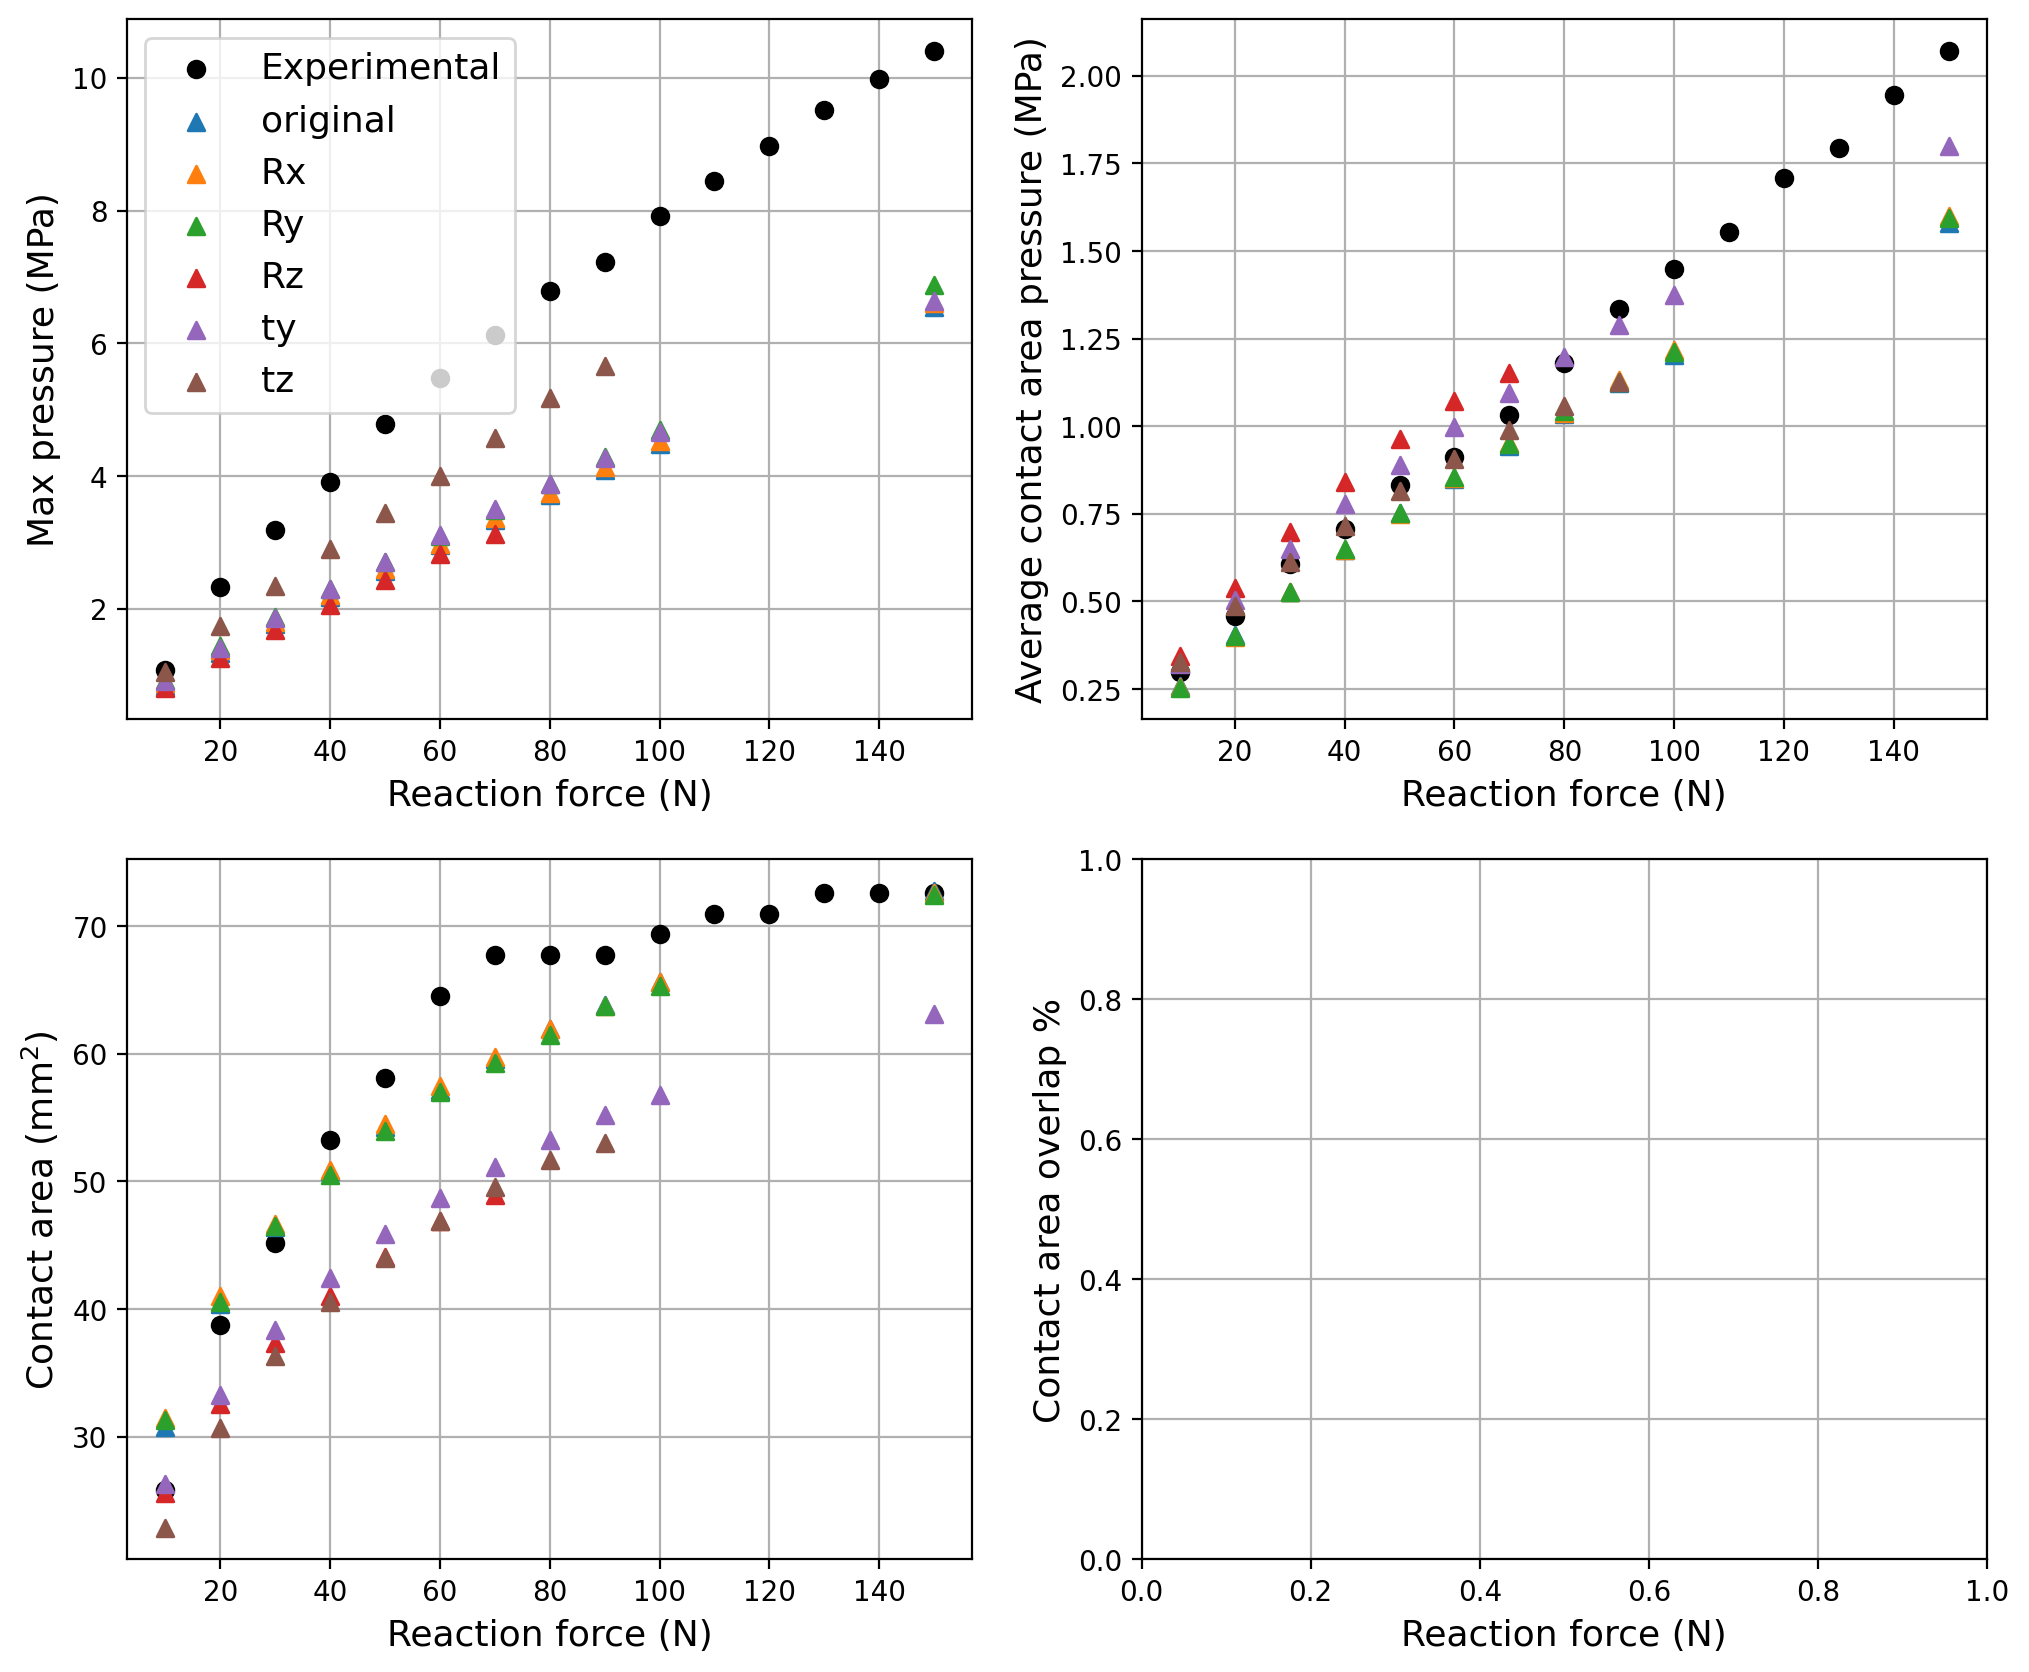

In [120]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "tek": "#000000", #"#0097b2",
         #"#009e73"
    "FE downscaled": "#e67a14",
    'FE raw': "#cc79a7"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o", 
    "FE downscaled": "^",
    'FE raw': "^"
}

for F in tek_data:
    tek_mets = compute_img_metrics(tek_data[F])

    label_tek = 'Experimental' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)
    #ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

for i, fea_data in enumerate(fe_data):
    for F in fea_data:
        fea_mets = fea_mets_from_mesh(fea_data[F][bone])

        label_fe = names[i] if F==10 else None
        ax[0].scatter(F, fea_mets['P_max'], c=f'C{i}', marker=markers['FE raw'], label=label_fe, zorder=2)
        ax[1].scatter(F, fea_mets['P_avg'], c=f'C{i}', marker=markers['FE raw'], zorder=2)
        ax[2].scatter(F, fea_mets['CA'], c=f'C{i}', marker=markers['FE raw'], zorder=2)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

### Downscaled FE

In [121]:
fe_grid = get_fe_grid_data(fe, Fs, tek_data)
fe_Rx_grid = get_fe_grid_data(fe_Rx, Fs, tek_data)
fe_Ry_grid = get_fe_grid_data(fe_Ry, Fs, tek_data)
fe_Rz_grid = get_fe_grid_data(fe_Rz, Fs[:7], tek_data)
fe_ty_grid = get_fe_grid_data(fe_ty, Fs, tek_data)
fe_tz_grid = get_fe_grid_data(fe_tz, Fs[:9], tek_data)

fe_data_grids = [fe_grid, fe_Rx_grid, fe_Ry_grid, fe_Rz_grid, fe_ty_grid, fe_tz_grid]

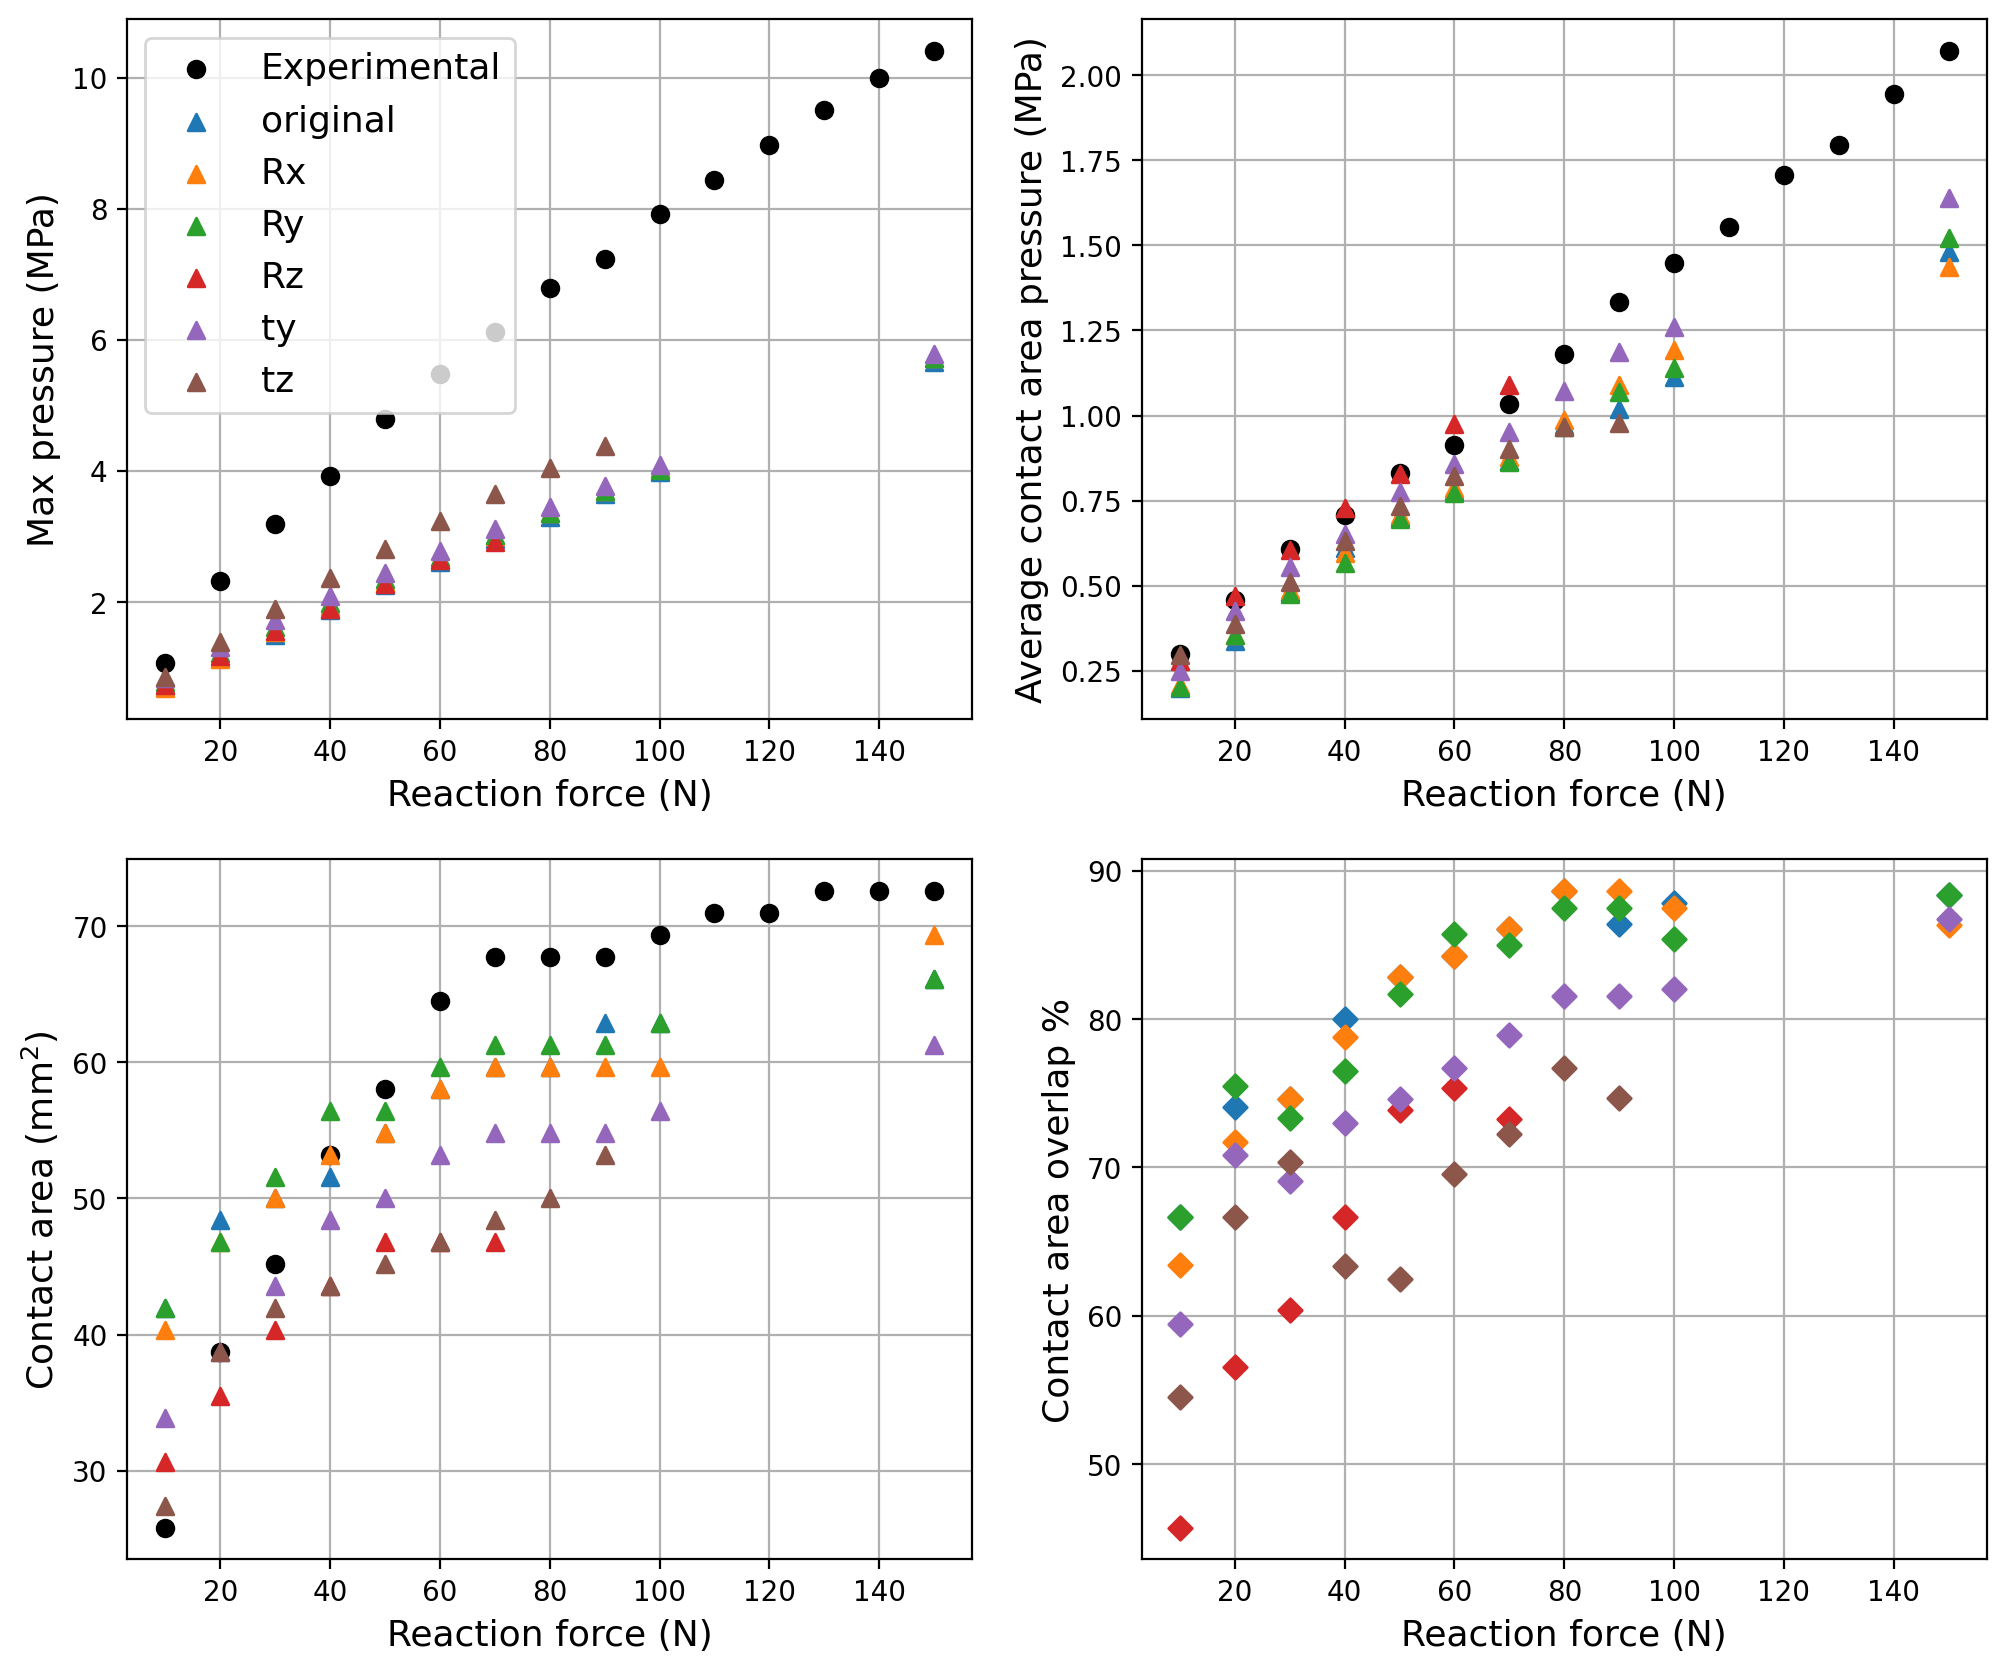

In [122]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "tek": "#000000", #"#0097b2",
         #"#009e73"
    "FE downscaled": "#e67a14",
    'FE raw': "#cc79a7"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o", 
    "FE downscaled": "^",
    'FE raw': "^"
}

for F in tek_data:
    tek_mets = compute_img_metrics(tek_data[F])

    label_tek = 'Experimental' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)
    #ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

for i, fea_data in enumerate(fe_data_grids):
    c = f'C{i}'
    for F in fea_data:
        fea_mets = compute_img_metrics(fea_data[F])

        label_fe = names[i] if F==10 else None
        ax[0].scatter(F, fea_mets['P_max'], c=c, marker=markers['FE raw'], label=label_fe, zorder=2)
        ax[1].scatter(F, fea_mets['P_avg'], c=c, marker=markers['FE raw'], zorder=2)
        ax[2].scatter(F, fea_mets['CA'], c=c, marker=markers['FE raw'], zorder=2)

        ax[3].scatter(F, compute_CA_overlap(fea_data[F], tek_data[F]), c=c, marker="D", label=label_fe, zorder=2)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

### Tekscan

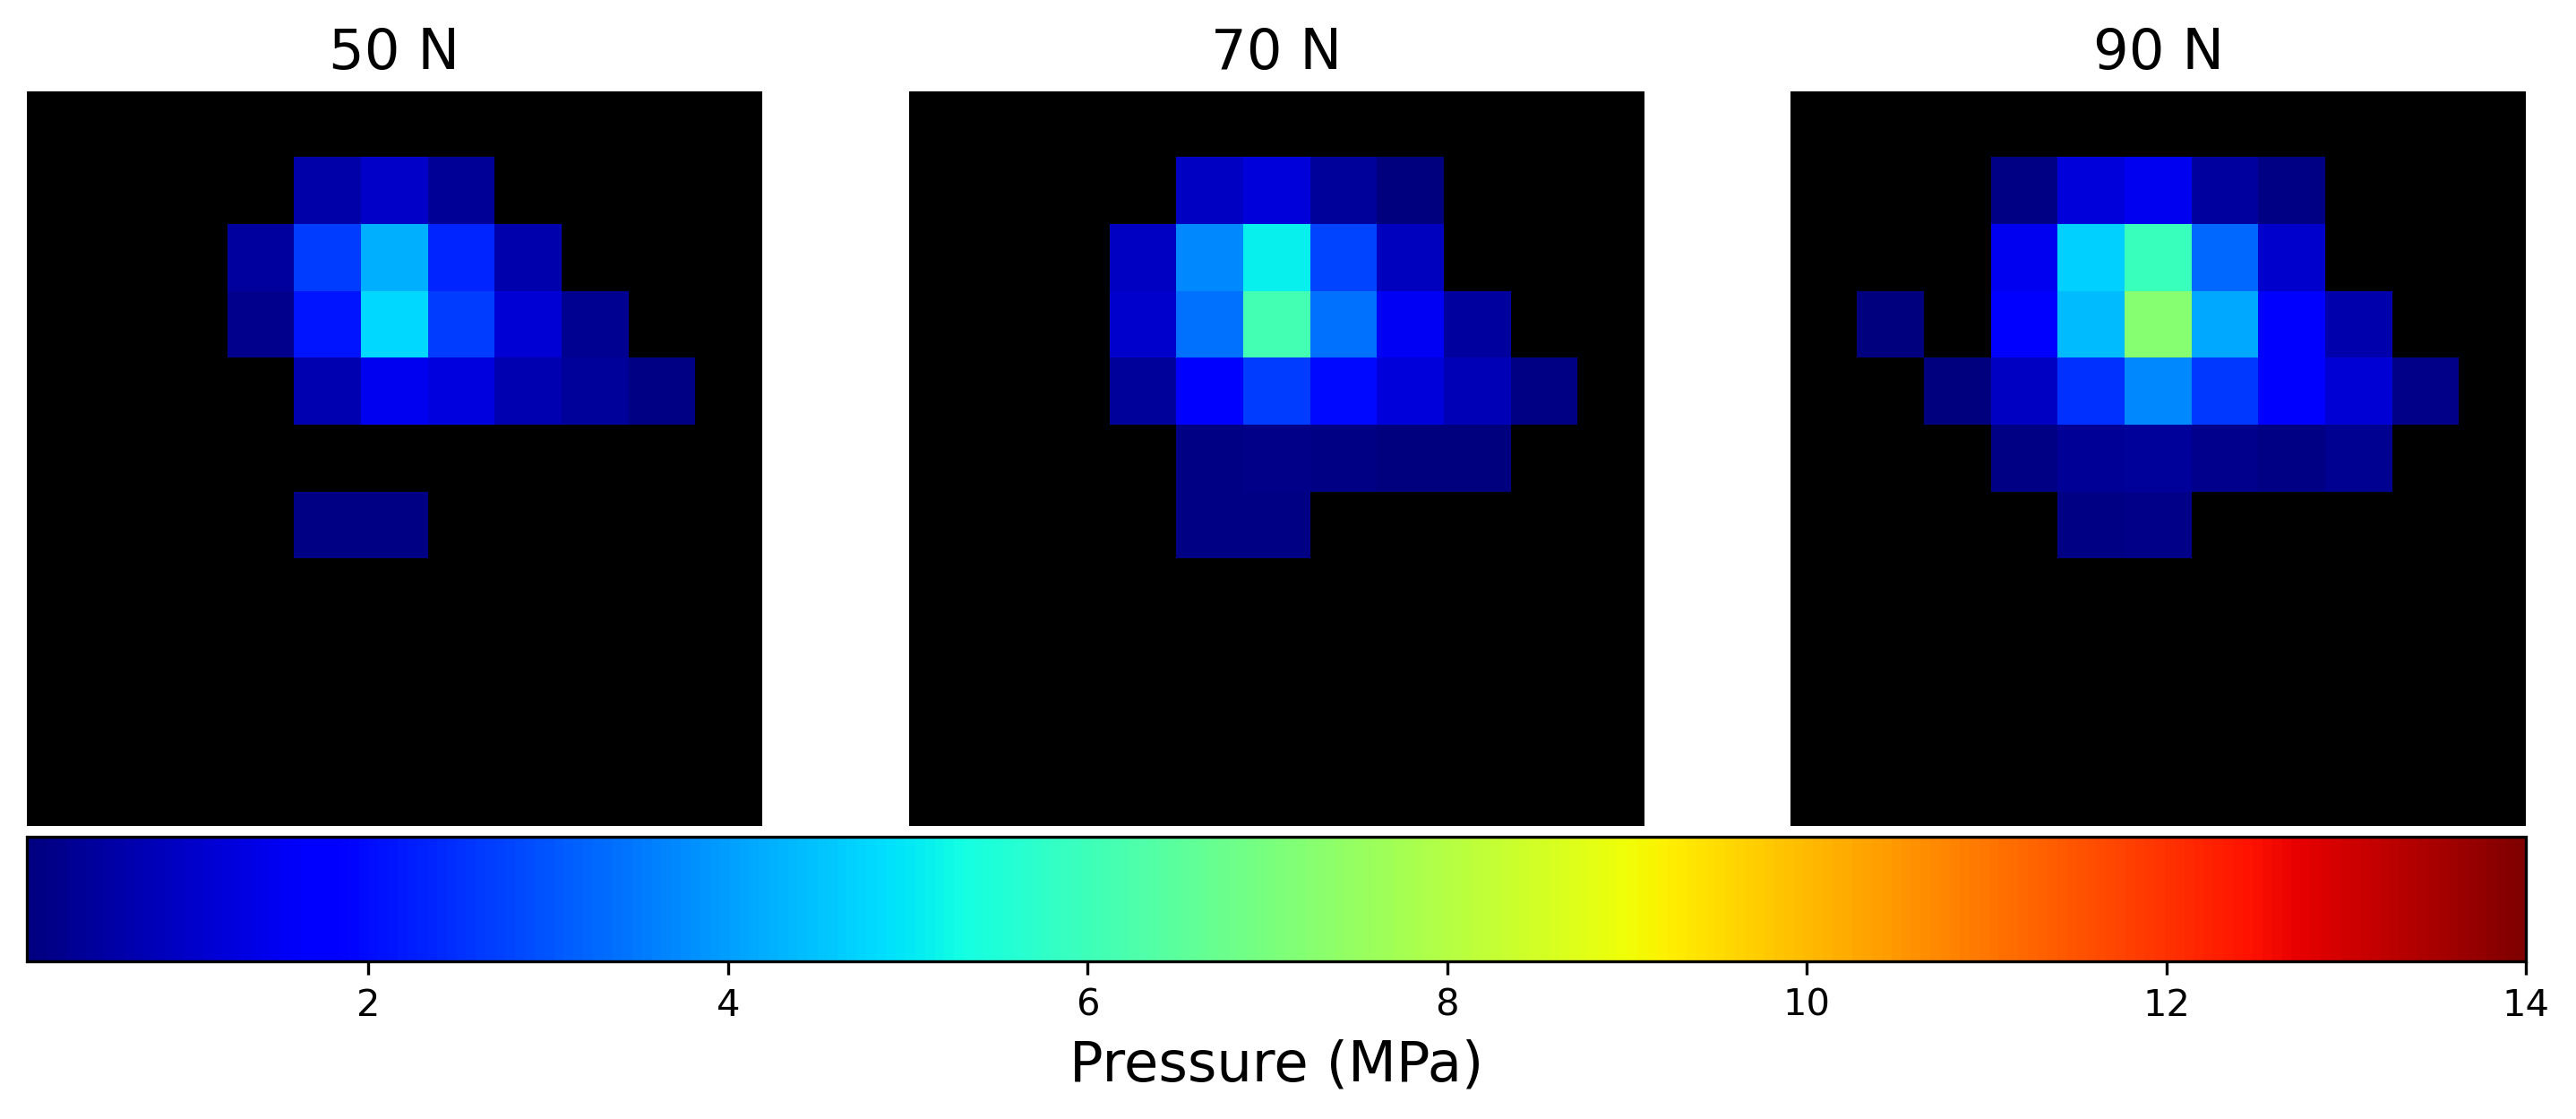

In [123]:
fig, ax = plt.subplots(1,3, figsize=(12, 5), dpi=300)

Fs = [50, 70, 90]

#press_max = max([np.max(tek_data[F][::-1]) for F in Fs])
cmap = plt.cm.jet.copy()
cmap.set_under('black')

for F, a in zip(Fs, ax):
    im = a.imshow(tek_data[F][::-1], cmap=cmap, vmin=0.1, vmax=14)
    a.axis('off')
    a.set_title(f"{F} N", fontsize=15)


cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.01) 
cbar.set_label('Pressure (MPa)', fontsize=15) 
plt.show()

### FE

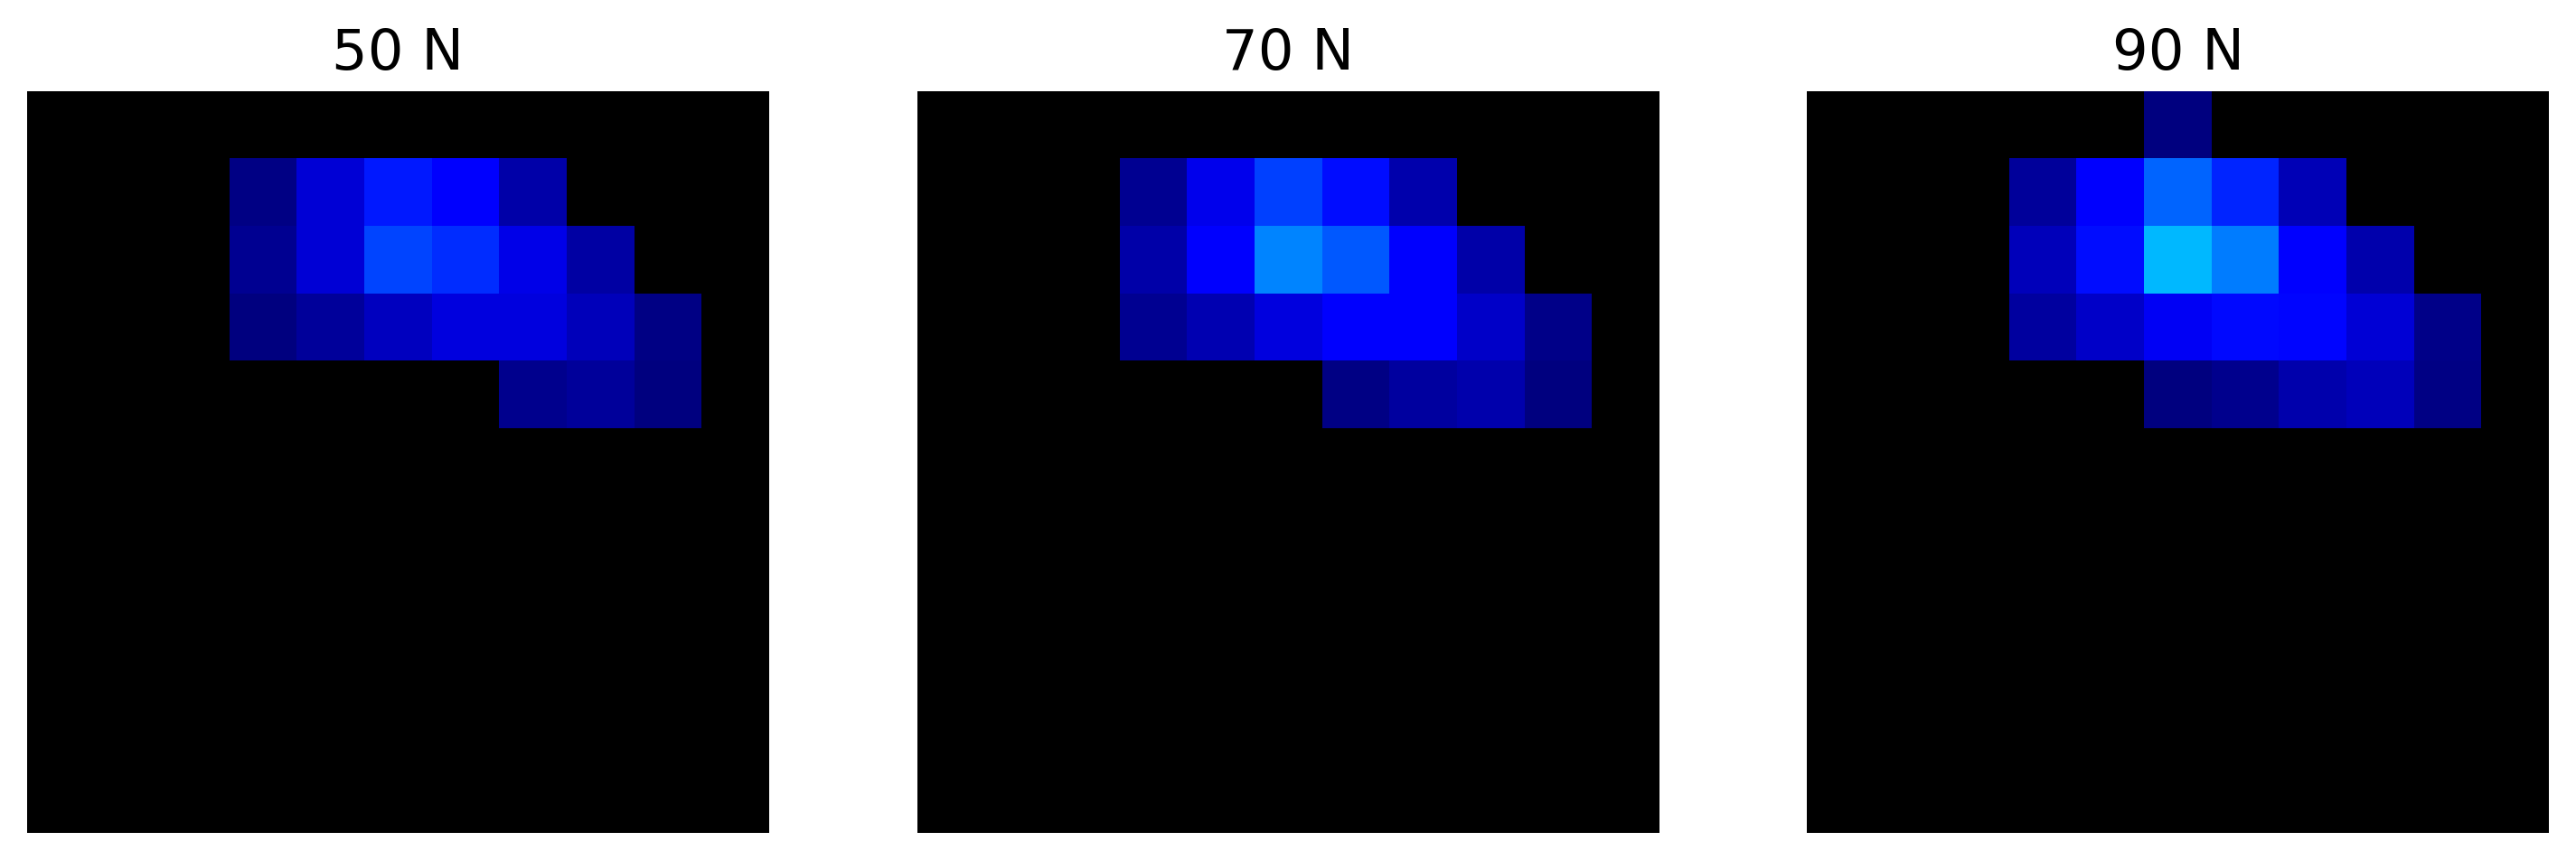

In [124]:
fea_grid_data = fe_data_grids[5]

fig, ax = plt.subplots(1,3, figsize=(12, 5), dpi=300)

#Fs = [50, 70, 90]

#press_max = max([np.max(tek_data[F][::-1]) for F in Fs])
cmap = plt.cm.jet.copy()
cmap.set_under('black')

for F, a in zip(Fs, ax):
    im = a.imshow(fea_grid_data[F][::-1], cmap=cmap, vmin=0.1, vmax=14)
    a.axis('off')
    a.set_title(f"{F} N", fontsize=15)


#cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.01) 
#cbar.set_label('Pressure (MPa)', fontsize=15) 
plt.show()